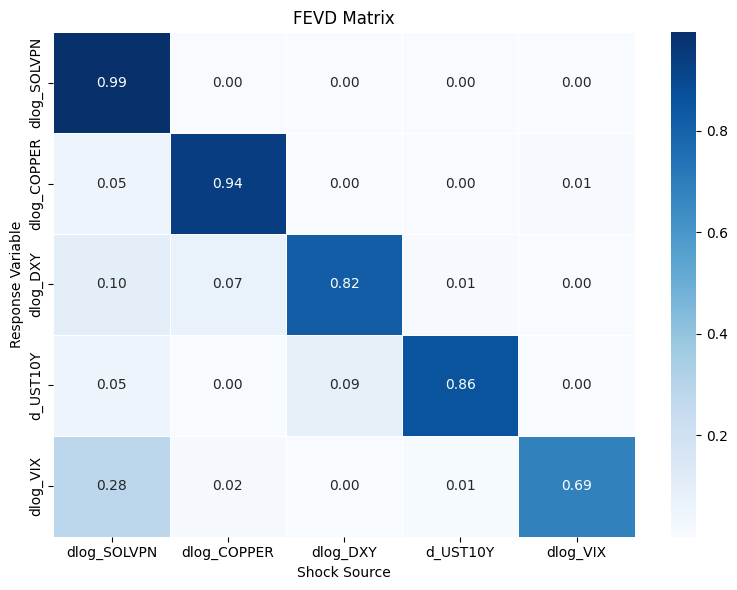

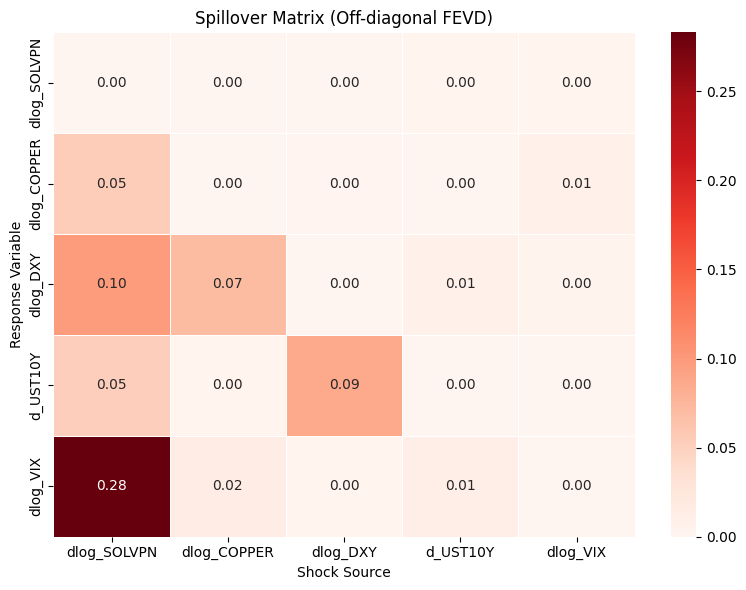


Directional Spillover
                   TO      FROM       NET
dlog_SOLVPN  0.487585  0.005667  0.481918
dlog_COPPER  0.088656  0.062307  0.026349
dlog_DXY     0.091291  0.178705 -0.087415
d_UST10Y     0.021377  0.143189 -0.121812
dlog_VIX     0.013983  0.313022 -0.299039


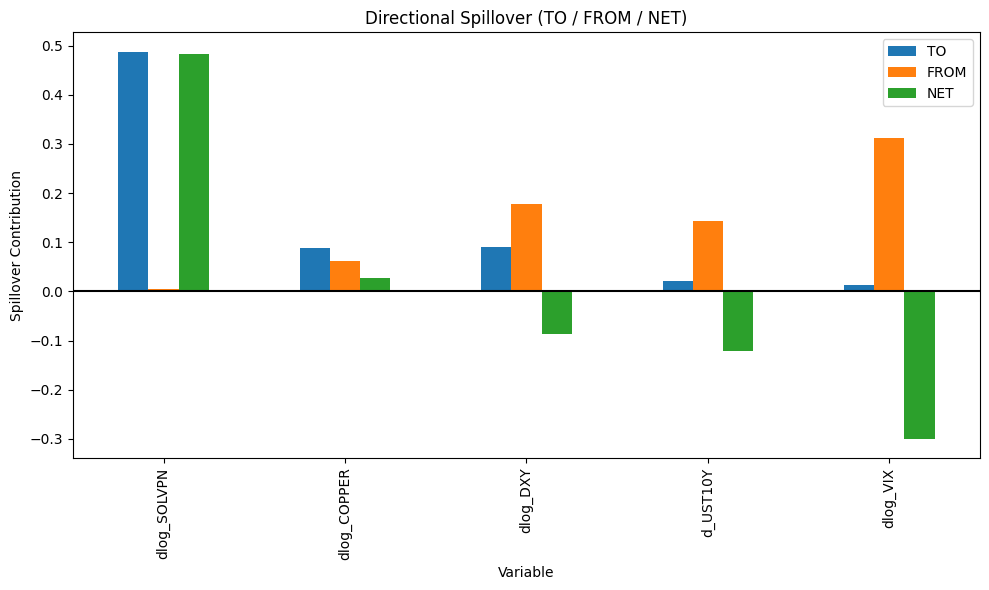

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================
# FEVD 결과 불러오기
# ============================

fevd = pd.read_csv("./fevd_final_horizon.csv", index_col=0)

# ============================
# 1️⃣ FEVD Heatmap (기존 코드)
# ============================

plt.figure(figsize=(8,6))

sns.heatmap(
    fevd,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)

plt.title("FEVD Matrix")
plt.xlabel("Shock Source")
plt.ylabel("Response Variable")

plt.tight_layout()
plt.savefig("fevd_heatmap.png", dpi=300)
plt.show()


# ============================
# 2️⃣ Spillover Matrix (Diagonal 제거)
# ============================

spill = fevd.copy()

# diagonal 제거
np.fill_diagonal(spill.values, 0)

plt.figure(figsize=(8,6))

sns.heatmap(
    spill,
    annot=True,
    cmap="Reds",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Spillover Matrix (Off-diagonal FEVD)")
plt.xlabel("Shock Source")
plt.ylabel("Response Variable")

plt.tight_layout()
plt.savefig("spillover_matrix.png", dpi=300)
plt.show()


# ============================
# 3️⃣ Directional Spillover 계산
# ============================

# FROM (다른 변수로부터 받는 영향)
FROM = spill.sum(axis=1)

# TO (다른 변수에 주는 영향)
TO = spill.sum(axis=0)

# NET spillover
NET = TO - FROM

spillover_df = pd.DataFrame({
    "TO": TO,
    "FROM": FROM,
    "NET": NET
})

print("\nDirectional Spillover")
print(spillover_df)


# ============================
# 4️⃣ Directional Spillover 그래프
# ============================

spillover_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Directional Spillover (TO / FROM / NET)")
plt.ylabel("Spillover Contribution")
plt.xlabel("Variable")

plt.axhline(0, color="black")

plt.tight_layout()
plt.savefig("directional_spillover.png", dpi=300)
plt.show()